In [2]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import cv2
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops

from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     accuracy_score, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [3]:
DATASET_PATH = r'C:\Users\BALU LOHITH REDDY\Downloads\archive\tobacco leaves'

FOLDER_TO_GRADE = {
    'gold':  (0, 'Grade A', 'Gold'),
    'green': (1, 'Grade B', 'Yellowish-Green'),
    'black': (2, 'Grade C', 'Dark Brown'),
}

GRADE_LABELS  = ['Grade A (Gold)', 'Grade B (Green)', 'Grade C (Black)']
SHORT_LABELS  = ['A', 'B', 'C']
IMG_SIZE      = (224, 224)      # resize all images to this
MODEL_FILE    = 'tobacco_grader.pkl'
RANDOM_STATE  = 42

In [4]:
def remove_background(img_bgr):
    """Remove white background, return (masked_img, mask)."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    # White pixels: low saturation + high brightness
    bg  = cv2.inRange(hsv, np.array([0, 0, 190]), np.array([180, 40, 255]))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    bg  = cv2.morphologyEx(bg, cv2.MORPH_CLOSE, kernel)
    bg  = cv2.morphologyEx(bg, cv2.MORPH_OPEN,  kernel)
    mask = cv2.bitwise_not(bg)

    # Keep largest connected component (the leaf)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.uint8(labels == largest) * 255

    masked = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return masked, mask


def color_features(img_bgr, mask):
    feats = []
    has_mask = mask is not None and np.any(mask > 0)

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    if has_mask:
        h = hsv[mask > 0, 0].astype(np.float32)
        s = hsv[mask > 0, 1].astype(np.float32)
        v = hsv[mask > 0, 2].astype(np.float32)
    else:
        h = hsv[:, :, 0].flatten().astype(np.float32)
        s = hsv[:, :, 1].flatten().astype(np.float32)
        v = hsv[:, :, 2].flatten().astype(np.float32)

    h_hist, _ = np.histogram(h, bins=18, range=(0, 180), density=True)
    s_hist, _ = np.histogram(s, bins=8,  range=(0, 255), density=True)
    v_hist, _ = np.histogram(v, bins=8,  range=(0, 255), density=True)
    feats.extend(h_hist);  feats.extend(s_hist);  feats.extend(v_hist)

   
    feats += [np.mean(h), np.std(h), np.median(h)]
    feats += [np.mean(s), np.std(s)]
    feats += [np.mean(v), np.std(v)]

    
    for p in [10, 25, 50, 75, 90]:
        feats.append(float(np.percentile(v, p)) / 255.0)

   
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    if has_mask:
        lab_px = lab[mask > 0]
    else:
        lab_px = lab.reshape(-1, 3)
    for ch in range(3):
        feats.append(float(np.mean(lab_px[:, ch])))
        feats.append(float(np.std(lab_px[:, ch])))

   
    if has_mask:
        px = img_bgr[mask > 0].astype(float)
    else:
        px = img_bgr.reshape(-1, 3).astype(float)
    b_ch, g_ch, r_ch = px[:, 0], px[:, 1], px[:, 2]
    total = np.mean(r_ch) + np.mean(g_ch) + np.mean(b_ch) + 1e-6
    feats += [np.mean(r_ch)/total, np.mean(g_ch)/total, np.mean(b_ch)/total]
    feats += [np.mean(r_ch) - np.mean(b_ch)]   
    feats += [np.mean(g_ch) - np.mean(b_ch)]  

    return np.array(feats, dtype=np.float32)

def texture_features(img_bgr, mask):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (256, 256))
    feats = []

    glcm = graycomatrix(gray, distances=[1, 3, 5],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    for prop in ['contrast', 'correlation', 'energy', 'homogeneity']:
        vals = graycoprops(glcm, prop).flatten()
        feats += [float(np.mean(vals)), float(np.std(vals)),
                  float(np.min(vals)),  float(np.max(vals))]

    eps = 1e-10
    entropy = -np.sum(glcm * np.log2(glcm + eps), axis=(0, 1)).flatten()
    feats += [float(np.mean(entropy)), float(np.std(entropy))]

    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gm = np.sqrt(sx**2 + sy**2).flatten()
    feats += [float(np.mean(gm)), float(np.std(gm)), float(np.percentile(gm, 75))]

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    feats.append(float(np.var(lap)))

    return np.array(feats, dtype=np.float32)

def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f'Cannot read: {img_path}')
    img = cv2.resize(img, IMG_SIZE)
    img_masked, mask = remove_background(img)

    if np.sum(mask > 0) < IMG_SIZE[0] * IMG_SIZE[1] * 0.05:
        img_masked, mask = img, None

    cf = color_features(img_masked, mask)
    tf = texture_features(img_masked, mask)
    return np.concatenate([cf, tf])


print('Feature functions defined')
print(f'   Feature vector size: {len(extract_features(glob.glob(os.path.join(DATASET_PATH, "gold", "*.jpg"))[0]))} values')

Feature functions defined
   Feature vector size: 79 values


In [5]:
X_list, y_list, paths_list = [], [], []
errors = 0

print(' Extracting features from all images...\n')
t_start = time.time()

for folder, (label, grade, desc) in FOLDER_TO_GRADE.items():
    folder_path = os.path.join(DATASET_PATH, folder)
    images = (glob.glob(os.path.join(folder_path, '*.jpg')) +
              glob.glob(os.path.join(folder_path, '*.jpeg')) +
              glob.glob(os.path.join(folder_path, '*.png')))

    print(f'{folder}/  →  {grade} ({desc}):  {len(images)} images')

    for img_path in tqdm(images, desc=f'  {folder}', ncols=70):
        try:
            feats = extract_features(img_path)
            X_list.append(feats)
            y_list.append(label)
            paths_list.append(img_path)
        except Exception as e:
            errors += 1

X = np.array(X_list)
y = np.array(y_list)

elapsed = time.time() - t_start

print(f'\n Done in {elapsed:.1f}s')
print(f'   Total images  : {len(X)}')
print(f'   Feature size  : {X.shape[1]} values per image')
print(f'   Errors skipped: {errors}')
print(f'\n   Class distribution:')
for label, (idx, grade, desc) in FOLDER_TO_GRADE.items():
    count = np.sum(y == idx)
    print(f'     {grade} ({desc}): {count} images')

 Extracting features from all images...

gold/  →  Grade A (Gold):  178 images


  gold: 100%|███████████████████████| 178/178 [00:34<00:00,  5.15it/s]


green/  →  Grade B (Yellowish-Green):  100 images


  green: 100%|██████████████████████| 100/100 [00:21<00:00,  4.76it/s]


black/  →  Grade C (Dark Brown):  185 images


  black: 100%|██████████████████████| 185/185 [00:57<00:00,  3.21it/s]


 Done in 113.4s
   Total images  : 463
   Feature size  : 79 values per image
   Errors skipped: 0

   Class distribution:
     Grade A (Gold): 178 images
     Grade B (Yellowish-Green): 100 images
     Grade C (Dark Brown): 185 images


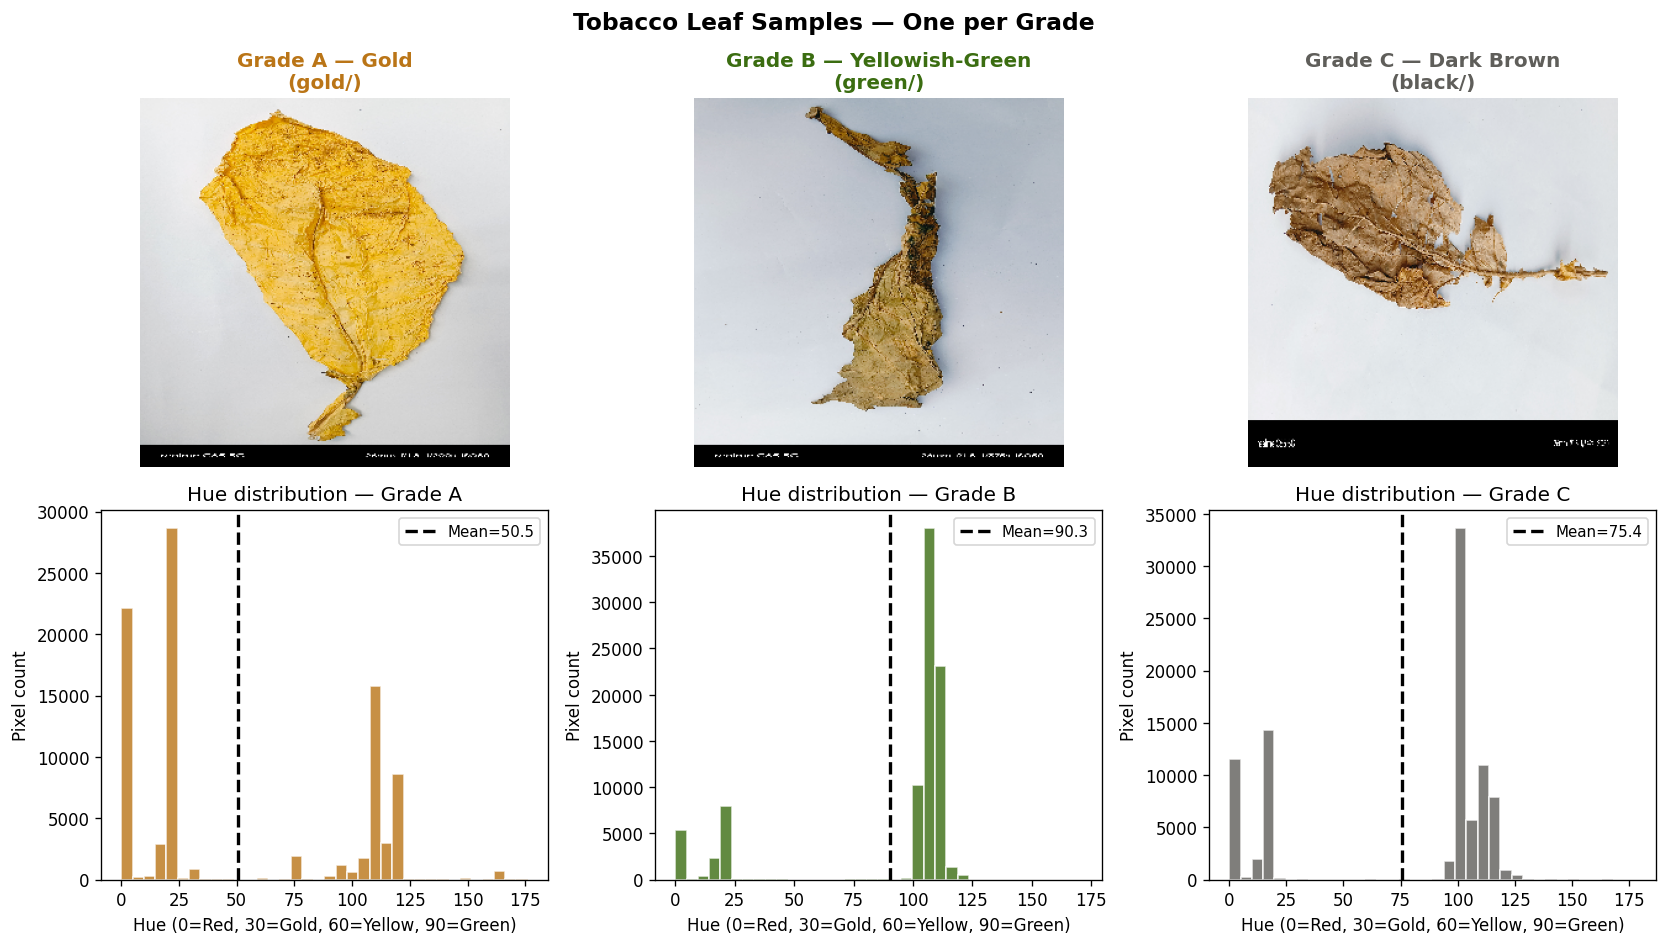

Saved: sample_visualization.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Tobacco Leaf Samples — One per Grade', fontsize=14, fontweight='bold')

colors = {'gold': '#BA7517', 'green': '#3B6D11', 'black': '#5F5E5A'}

for col, (folder, (label, grade, desc)) in enumerate(FOLDER_TO_GRADE.items()):
    imgs = glob.glob(os.path.join(DATASET_PATH, folder, '*.jpg'))[:1]
    if not imgs:
        continue
    img = cv2.imread(imgs[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_r = cv2.resize(img_rgb, (300, 300))

    # Original
    axes[0, col].imshow(img_r)
    axes[0, col].set_title(f'{grade} — {desc}\n({folder}/)', 
                            color=colors[folder], fontweight='bold')
    axes[0, col].axis('off')

    # HSV Hue histogram
    hsv = cv2.cvtColor(cv2.resize(img, (300, 300)), cv2.COLOR_BGR2HSV)
    h_vals = hsv[:, :, 0].flatten()
    axes[1, col].hist(h_vals, bins=36, color=colors[folder], alpha=0.8, edgecolor='white')
    axes[1, col].set_xlabel('Hue (0=Red, 30=Gold, 60=Yellow, 90=Green)')
    axes[1, col].set_ylabel('Pixel count')
    axes[1, col].set_title(f'Hue distribution — {grade}')
    axes[1, col].axvline(np.mean(h_vals), color='black', lw=2, linestyle='--', 
                          label=f'Mean={np.mean(h_vals):.1f}')
    axes[1, col].legend(fontsize=9)

plt.tight_layout()
plt.savefig('sample_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_visualization.png')

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,             # keeps A/B/C ratio same in both splits
    random_state=RANDOM_STATE
)

print('Data split complete')
print(f'   Training set : {len(X_train)} images  ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test set     : {len(X_test)}  images  ({len(X_test)/len(X)*100:.0f}%)')
print()
print('   Training class counts:')
for i, grade in enumerate(GRADE_LABELS):
    print(f'     {grade}: {np.sum(y_train == i)}')

Data split complete
   Training set : 370 images  (80%)
   Test set     : 93  images  (20%)

   Training class counts:
     Grade A (Gold): 142
     Grade B (Green): 80
     Grade C (Black): 148


In [8]:
# Build 3 pipelines: StandardScaler → Classifier
# Scaling is important: GLCM values (~0-8) and histograms (0-1) are different scales

pipelines = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            n_estimators=300,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('Cross-validating models (5-fold)...\n')
for name, pipe in pipelines.items():
    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    bar = '' * int(scores.mean() * 30)
    print(f'  {name:<22}  {bar}')
    print(f'  {" "*22}  Acc: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%  '
          f'({time.time()-t0:.1f}s)\n')

best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_score = cv_results[best_model_name].mean()
print(f'\n Best model: {best_model_name}  →  {best_score*100:.2f}% accuracy')

Cross-validating models (5-fold)...

  Random Forest           
                          Acc: 94.86% ± 1.01%  (9.1s)

  SVM (RBF)               
                          Acc: 94.32% ± 2.32%  (3.9s)

  Gradient Boosting       
                          Acc: 93.78% ± 1.38%  (13.9s)


 Best model: Random Forest  →  94.86% accuracy


In [9]:
print(f'Training {best_model_name} on full training set...')
t0 = time.time()

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

print(f'Trained in {time.time()-t0:.1f}s')

# Save to file
bundle = {
    'model':        best_pipeline,
    'model_name':   best_model_name,
    'grade_labels': GRADE_LABELS,
    'short_labels': SHORT_LABELS,
    'img_size':     IMG_SIZE,
    'n_features':   X.shape[1],
    'folder_map':   FOLDER_TO_GRADE,
}
joblib.dump(bundle, MODEL_FILE, compress=3)
print(f' Model saved → {MODEL_FILE}')

Training Random Forest on full training set...
Trained in 1.3s
 Model saved → tobacco_grader.pkl


In [10]:
y_pred = best_pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print('='*55)
print(f'  TEST SET ACCURACY:  {acc*100:.2f}%')
print('='*55)
print()
print(classification_report(y_test, y_pred, target_names=GRADE_LABELS))

  TEST SET ACCURACY:  94.62%

                 precision    recall  f1-score   support

 Grade A (Gold)       0.92      1.00      0.96        36
Grade B (Green)       0.89      0.85      0.87        20
Grade C (Black)       1.00      0.95      0.97        37

       accuracy                           0.95        93
      macro avg       0.94      0.93      0.93        93
   weighted avg       0.95      0.95      0.95        93



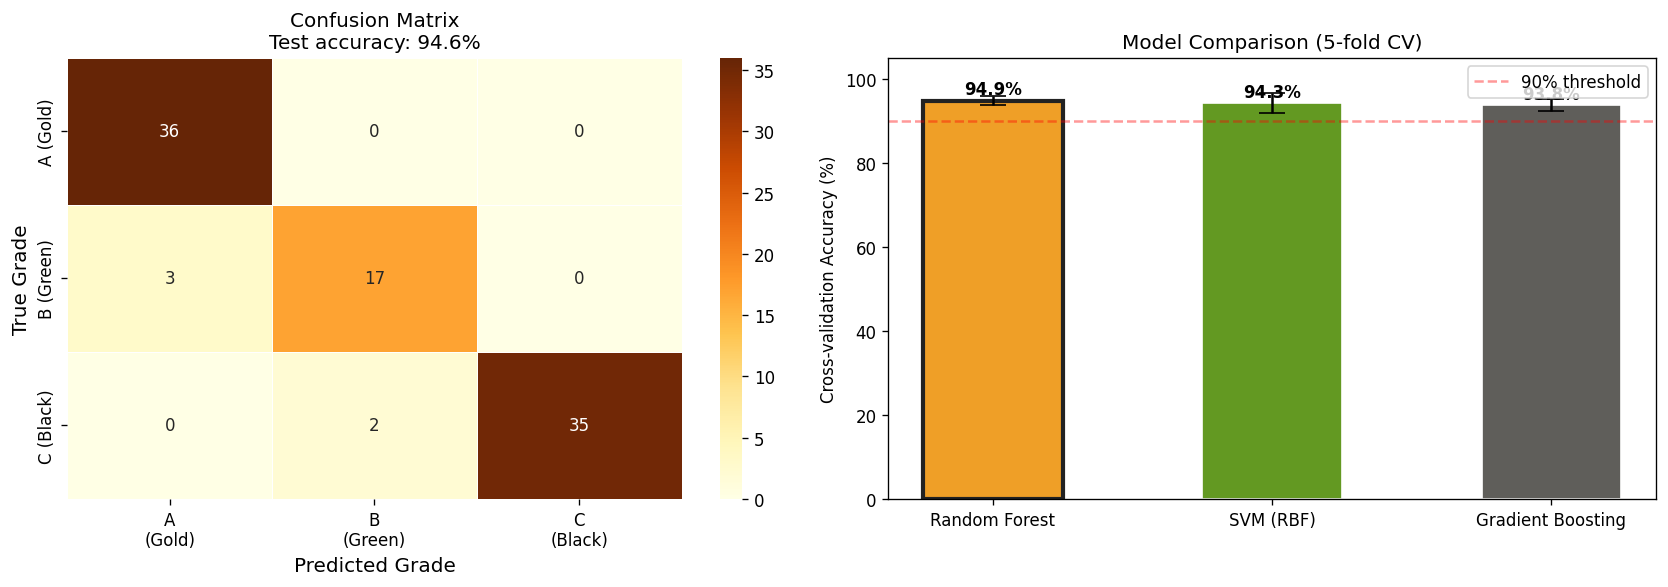

Saved: model_results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Confusion matrix ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['A\n(Gold)', 'B\n(Green)', 'C\n(Black)'],
            yticklabels=['A (Gold)', 'B (Green)', 'C (Black)'],
            linewidths=0.5, linecolor='white',
            ax=axes[0], cbar=True)
axes[0].set_xlabel('Predicted Grade', fontsize=12)
axes[0].set_ylabel('True Grade',      fontsize=12)
axes[0].set_title(f'Confusion Matrix\nTest accuracy: {acc*100:.1f}%', fontsize=12)

# ── Right: Cross-validation comparison ───────────────────────
model_names  = list(cv_results.keys())
means  = [cv_results[m].mean()*100 for m in model_names]
stds   = [cv_results[m].std()*100  for m in model_names]
colors_bar = ['#EF9F27', '#639922', '#5F5E5A']
bars = axes[1].bar(model_names, means, yerr=stds,
                   color=colors_bar, edgecolor='white',
                   capsize=8, width=0.5)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{mean:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Cross-validation Accuracy (%)')
axes[1].set_title('Model Comparison (5-fold CV)')
axes[1].set_ylim(0, 105)
axes[1].axhline(90, color='red', linestyle='--', alpha=0.4, label='90% threshold')
axes[1].legend()
best_bar = bars[model_names.index(best_model_name)]
best_bar.set_edgecolor('#222')
best_bar.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_results.png')

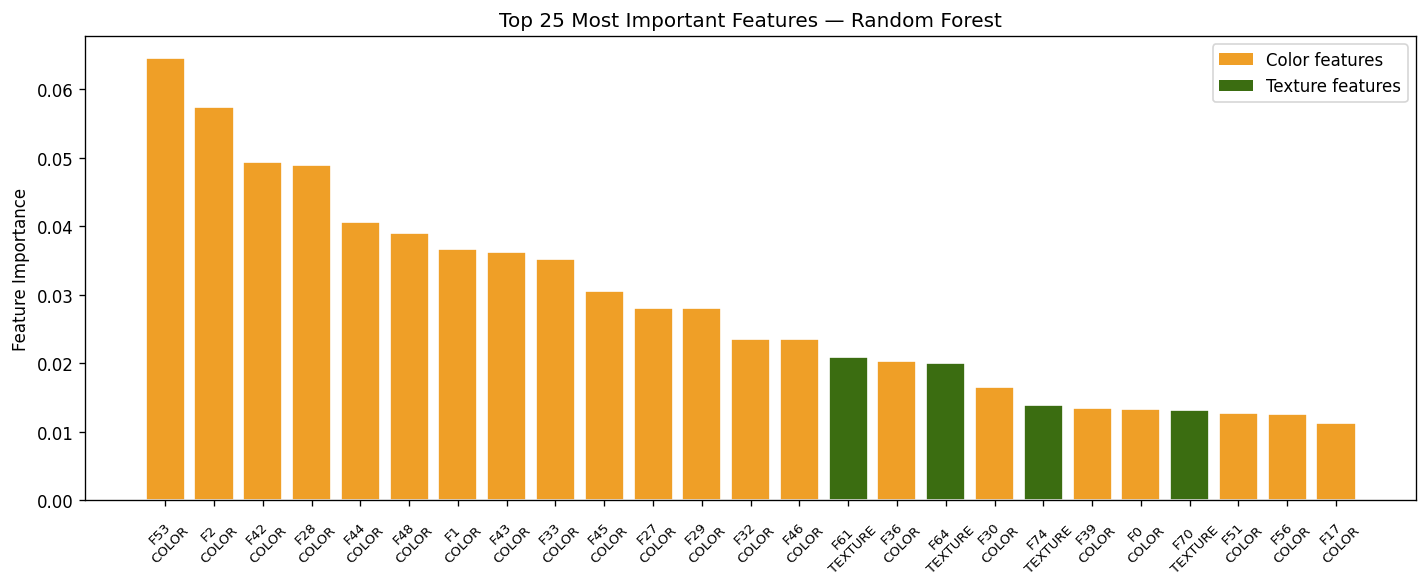

Saved: feature_importance.png


In [12]:
if best_model_name == 'Random Forest':
    clf = best_pipeline.named_steps['clf']
    importances = clf.feature_importances_
    top_n = 25
    idx = np.argsort(importances)[::-1][:top_n]

    # Label which feature group each index falls in
    n_color   = len(color_features(np.zeros((*IMG_SIZE, 3), dtype=np.uint8), None))
    feat_type = ['COLOR' if i < n_color else 'TEXTURE' for i in idx]
    bar_colors = ['#EF9F27' if t == 'COLOR' else '#3B6D11' for t in feat_type]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(top_n), importances[idx], color=bar_colors, edgecolor='white')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([f'F{i}\n{feat_type[j]}' for j, i in enumerate(idx)],
                        rotation=45, fontsize=8)
    ax.set_ylabel('Feature Importance')
    ax.set_title(f'Top {top_n} Most Important Features — {best_model_name}')

    from matplotlib.patches import Patch
    legend = [Patch(facecolor='#EF9F27', label='Color features'),
              Patch(facecolor='#3B6D11', label='Texture features')]
    ax.legend(handles=legend)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: feature_importance.png')
else:
    print(f'Feature importance not available for {best_model_name}')
    print('(Random Forest was not the best model)')

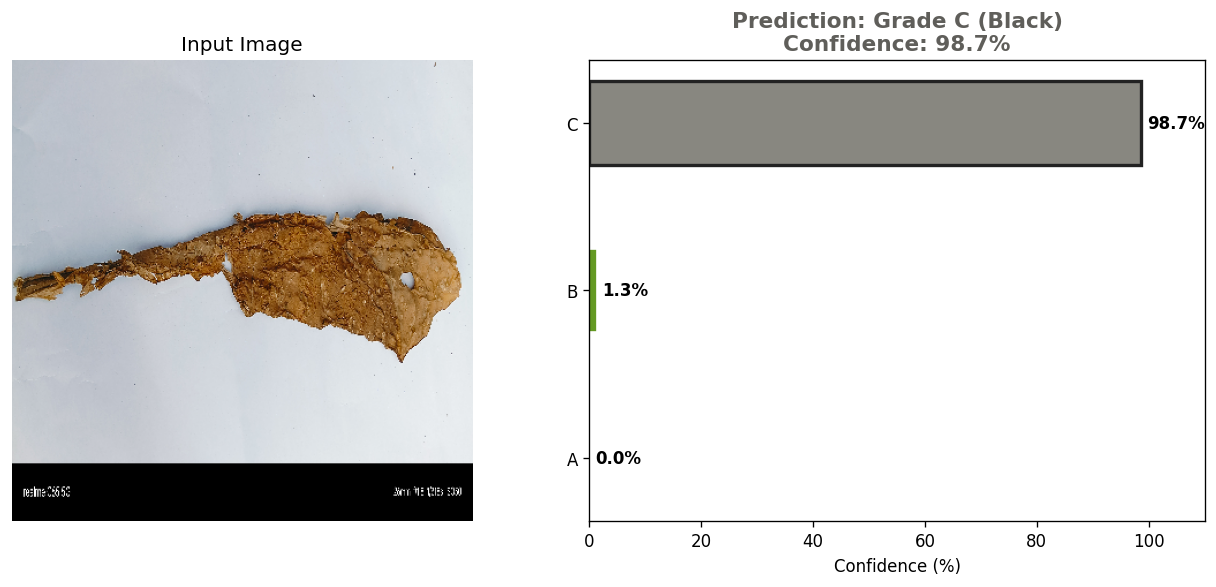


  RESULT → Grade C (Black)  (98.7% confidence)
  Probabilities:
    Grade A                                              0.0%
    Grade B                                              1.3%
    Grade C                                             98.7% ←


In [13]:
TEST_IMAGE_PATH = r'C:\Users\BALU LOHITH REDDY\Downloads\archive\tobacco leaves\black\IMG20250116141254.jpg'


feats = extract_features(TEST_IMAGE_PATH).reshape(1, -1)
pred_idx   = best_pipeline.predict(feats)[0]
pred_proba = best_pipeline.predict_proba(feats)[0]

grade_label = GRADE_LABELS[pred_idx]
confidence  = pred_proba[pred_idx] * 100

img = cv2.imread(TEST_IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

grade_colors = ['#BA7517', '#3B6D11', '#5F5E5A']
grade_color  = grade_colors[pred_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(cv2.resize(img_rgb, (400, 400)))
axes[0].set_title(f'Input Image', fontsize=12)
axes[0].axis('off')

bars = axes[1].barh(SHORT_LABELS, pred_proba * 100,
                    color=['#EF9F27', '#639922', '#888780'],
                    edgecolor='white', height=0.5)
axes[1].set_xlim(0, 110)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title(
    f'Prediction: {grade_label}\nConfidence: {confidence:.1f}%',
    color=grade_color, fontsize=13, fontweight='bold'
)
for bar, pct in zip(bars, pred_proba * 100):
    axes[1].text(pct + 1, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontweight='bold')

bars[pred_idx].set_edgecolor('#222')
bars[pred_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

print(f'\n  RESULT → {grade_label}  ({confidence:.1f}% confidence)')
print(f'  Probabilities:')
for i, (lbl, p) in enumerate(zip(SHORT_LABELS, pred_proba)):
    bar = '' * int(p * 40)
    marker = ' ←' if i == pred_idx else ''
    print(f'    Grade {lbl}  {bar:<40}  {p*100:5.1f}%{marker}')